# Running Palace Simulations: Mach Zehnder Modulator

[Palace](https://awslabs.github.io/palace/) is an open-source 3D electromagnetic simulator supporting eigenmode, driven (S-parameter), and electrostatic simulations. This notebook demonstrates using the `gsim.palace` API to run a driven simulation on a Mach Zehnder Modulator.

**Requirements:**

- [GDSFactory+](https://gdsfactory.com) account for cloud simulation

### Generate layout for MZM

/tmp/ipykernel_18910/2066520645.py:1: DeprecationWarning: The 'gdsfactory.generic_tech' module is deprecated and will be removed in a future version. Please update your imports to use 'gdsfactory.gpdk' instead:
  from gdsfactory.gpdk import LAYER, LAYER_STACK, get_generic_pdk
Or for submodules:
  from gdsfactory.gpdk.layer_map import LAYER
  from gdsfactory.gpdk.layer_stack import LAYER_STACK
  from gdsfactory.generic_tech import LAYER


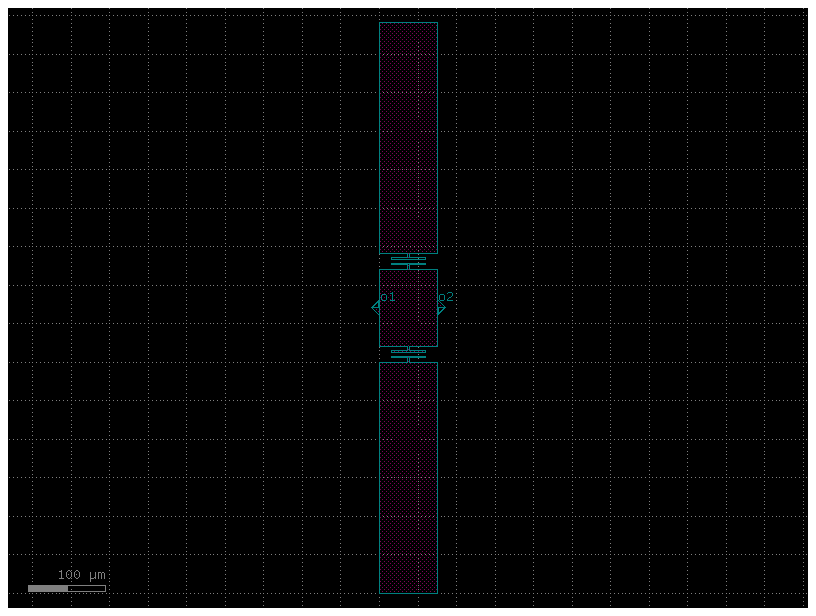

In [1]:
from gdsfactory.generic_tech import LAYER
import klayout.db as kdb

import gdsfactory as gf

gf.gpdk.PDK.activate()


def t_shape_dpoly(w1: float, w2: float, h1: float, h2: float) -> kdb.DPolygon:
    w3 = (w2 - w1) / 2
    return kdb.DPolygon(
        [
            kdb.DPoint(-w1 / 2, 0),
            kdb.DPoint(w1 / 2, 0),
            kdb.DPoint(w1 / 2, h1),
            kdb.DPoint(w1 / 2 + w3, h1),
            kdb.DPoint(w1 / 2 + w3, h1 + h2),
            kdb.DPoint(-w1 / 2 - w3, h1 + h2),
            kdb.DPoint(-w1 / 2 - w3, h1),
            kdb.DPoint(-w1 / 2, h1),
        ]
    )


def cpw_conductor(
    layer: tuple[int, int],
    gap: float,
    trace_width: float,
    ground_width: float,
    number_of_ts: int,
    w1: float,
    w2: float,
    h1: float,
    h2: float,
    t_spacing: float,
    port_length: float,
) -> gf.Component:
    comp = gf.Component()
    board_width = trace_width + 2 * ground_width + 2 * gap
    board_length = number_of_ts * (w2 + t_spacing) + t_spacing + port_length * 2
    midwidth = board_width / 2
    x_start = port_length + t_spacing

    def dpoly_to_ipoly(dp: kdb.DPolygon) -> kdb.Polygon:
        dbu = comp.kcl.dbu
        return dp.to_itype(dbu)

    trace = kdb.Region()
    rect_trace = kdb.DPolygon(
        [
            kdb.DPoint(0, midwidth - trace_width / 2),
            kdb.DPoint(board_length, midwidth - trace_width / 2),
            kdb.DPoint(board_length, midwidth + trace_width / 2),
            kdb.DPoint(0, midwidth + trace_width / 2),
        ]
    )
    trace.insert(dpoly_to_ipoly(rect_trace))

    for i in range(number_of_ts):
        dp = t_shape_dpoly(w1, w2, h1, h2)
        dp = dp.transformed(
            kdb.DTrans(
                x_start + i * (w2 + t_spacing) + w2 / 2, midwidth + trace_width / 2
            )
        )
        trace.insert(dpoly_to_ipoly(dp))

    for i in range(number_of_ts):
        dp = t_shape_dpoly(w1, w2, h1, h2)
        dp = dp.transformed(kdb.DTrans(kdb.DTrans.R180))
        dp = dp.transformed(
            kdb.DTrans(
                x_start + i * (w2 + t_spacing) + w2 / 2, midwidth - trace_width / 2
            )
        )
        trace.insert(dpoly_to_ipoly(dp))

    trace.merge()
    comp.add_polygon(trace, layer=layer)

    ground_lower = kdb.Region()
    rect_gL = kdb.DPolygon(
        [
            kdb.DPoint(0, midwidth - trace_width / 2 - gap),
            kdb.DPoint(0, midwidth - trace_width / 2 - gap - ground_width),
            kdb.DPoint(board_length, midwidth - trace_width / 2 - gap - ground_width),
            kdb.DPoint(board_length, midwidth - trace_width / 2 - gap),
        ]
    )
    ground_lower.insert(dpoly_to_ipoly(rect_gL))

    for i in range(number_of_ts):
        dp = t_shape_dpoly(w1, w2, h1, h2)
        dp = dp.transformed(
            kdb.DTrans(
                x_start + i * (w2 + t_spacing) + w2 / 2,
                midwidth - trace_width / 2 - gap,
            )
        )
        ground_lower.insert(dpoly_to_ipoly(dp))

    ground_lower.merge()
    comp.add_polygon(ground_lower, layer=layer)

    ground_upper = kdb.Region()
    rect_gU = kdb.DPolygon(
        [
            kdb.DPoint(0, midwidth + trace_width / 2 + gap),
            kdb.DPoint(0, midwidth + trace_width / 2 + gap + ground_width),
            kdb.DPoint(board_length, midwidth + trace_width / 2 + gap + ground_width),
            kdb.DPoint(board_length, midwidth + trace_width / 2 + gap),
        ]
    )
    ground_upper.insert(dpoly_to_ipoly(rect_gU))

    for i in range(number_of_ts):
        dp = t_shape_dpoly(w1, w2, h1, h2)
        dp = dp.transformed(kdb.DTrans(kdb.DTrans.R180))
        dp = dp.transformed(
            kdb.DTrans(
                x_start + i * (w2 + t_spacing) + w2 / 2,
                midwidth + trace_width / 2 + gap,
            )
        )
        ground_upper.insert(dpoly_to_ipoly(dp))

    ground_upper.merge()
    comp.add_polygon(ground_upper, layer=layer)

    return comp


def rib(
    layer: tuple[int, int],
    board_width: float,
    board_length: float,
    gap: float,
    trace_width: float,
    opt_width: float,
    port_length: float,
    t_spacing: float,
) -> gf.Component:
    rib_comp = gf.Component()
    midwidth = board_width / 2
    center = midwidth + trace_width / 2 + gap / 2
    offset = port_length + t_spacing
    rib_comp.add_polygon(
        [
            (offset, center - opt_width / 2),
            (board_length - offset, center - opt_width / 2),
            (board_length - offset, center + opt_width / 2),
            (offset, center + opt_width / 2),
        ],
        layer=layer,
    )
    center = midwidth - trace_width / 2 - gap / 2
    rib_comp.add_polygon(
        [
            (offset, center - opt_width / 2),
            (board_length - offset, center - opt_width / 2),
            (board_length - offset, center + opt_width / 2),
            (offset, center + opt_width / 2),
        ],
        layer=layer,
    )
    return rib_comp


def mach_zehnder_cpw(
    quartz_layer,
    siO2_layer,
    tfln_base_layer,
    tfln_rib_layer,
    conductor_layer,
    gap: float,
    trace_width: float,
    ground_width: float,
    rib_width: float,
    number_of_ts: int,
    t_w1: float,
    t_w2: float,
    t_h1: float,
    t_h2: float,
    t_spacing: float,
    port_length: float,
) -> gf.Component:
    comp = gf.Component()
    board_width = trace_width + 2 * ground_width + 2 * gap
    board_length = number_of_ts * (t_w2 + t_spacing) + t_spacing + port_length * 2
    cpw_comp = cpw_conductor(
        layer=conductor_layer,
        gap=gap,
        trace_width=trace_width,
        ground_width=ground_width,
        number_of_ts=number_of_ts,
        w1=t_w1,
        w2=t_w2,
        h1=t_h1,
        h2=t_h2,
        t_spacing=t_spacing,
        port_length=port_length,
    )
    comp.add_ref(cpw_comp)

    # rib_comp = rib(
    #     layer=tfln_rib_layer.gds_layer,
    #     board_width=board_width,
    #     board_length=board_length,
    #     gap=gap,
    #     trace_width=trace_width,
    #     opt_width=rib_width,
    #     port_length=port_length,
    #     t_spacing=t_spacing,
    # )
    # comp.add_ref(rib_comp)

    midwidth = board_width / 2

    comp.add_port(
        name="o1",
        center=(0, midwidth),
        width=gap,
        orientation=180,
        port_type="electrical",
        layer=conductor_layer,
    )
    comp.add_port(
        name="o2",
        center=(board_length, midwidth),
        width=gap,
        orientation=0,
        port_type="electrical",
        layer=conductor_layer,
    )
    return comp


# T-shape parameters
number_of_ts = 1
w1 = 2  # width of the stem of the T
w2 = 45  # width of the T top bar
h1 = 6  # height of the stem of the T
h2 = 2  # height of the T top bar
spacing = 5  # spacing between Ts
trace_width = 100
ground_width = 300
MZM_CPW_GAP = 5 + 2 * (h1 + h2)  # gap + 2*(h1+h2) to ensure T shapes dont overlap

PORT_LENGTH = 10  # length of the port

mzm_cpw_comp = mach_zehnder_cpw(
    quartz_layer=LAYER.M3,
    siO2_layer=LAYER.M3,
    tfln_base_layer=LAYER.M3,
    tfln_rib_layer=LAYER.M3,
    conductor_layer=LAYER.M3,
    gap=MZM_CPW_GAP,
    trace_width=trace_width,
    ground_width=ground_width,
    rib_width=1,
    number_of_ts=number_of_ts,
    t_w1=w1,
    t_w2=w2,
    t_h1=h1,
    t_h2=h2,
    t_spacing=spacing,
    port_length=PORT_LENGTH,
)

# Draw and plot MZM CPW component
_mzm_cpw_comp = mzm_cpw_comp.copy()
_mzm_cpw_comp.draw_ports()
_mzm_cpw_comp.plot()

### Configure and run simulation with DrivenSim

In [2]:
from gsim.palace import DrivenSim

# Create simulation object
sim = DrivenSim()

# Set output directory
sim.set_output_dir("./palace-sim-mzm")

# Set the component geometry
sim.set_geometry(mzm_cpw_comp)

# Configure via ports (Metal1 ground plane to TopMetal2 signal)
# Configure left CPW port (o1)
sim.add_cpw_port(
    "o1", layer="metal3", s_width=trace_width, gap_width=MZM_CPW_GAP, length=PORT_LENGTH
)

# Configure right CPW port (o2)
sim.add_cpw_port(
    "o2", layer="metal3", s_width=trace_width, gap_width=MZM_CPW_GAP, length=PORT_LENGTH
)

# Configure driven simulation (frequency sweep for S-parameters)
sim.set_driven(fmin=1e9, fmax=100e9, num_points=40)

# Validate configuration
print(sim.validate_config())

Validation: PASSED
Warnings:
  - No stack configured. Will use active PDK with defaults.


In [3]:
sim.mesh(preset="coarse", planar_conductors=False, margin=0)
# sim.mesh(preset="coarse", periodic_axis="x")

Mesh Summary
Dimensions: 75.0 x 742.0 x 12.6 µm
Nodes:      1,883
Elements:   13,396
Tetrahedra: 8,002
Edge length: 0.40 - 35.17 µm
Quality:    0.340 (min: 0.001)
SICN:       0.374 (all valid)
----------------------------------------
Volumes (3):
  - SiO2 [1]
  - passive [2]
  - air [3]
Surfaces (11):
  - metal3_xy [4]
  - metal3_z [5]
  - P1_E0 [6]
  - P1_E1 [7]
  - P2_E0 [8]
  - P2_E1 [9]
  - SiO2__None [10]
  - SiO2__passive [11]
  - passive__None [12]
  - air__passive [13]
  - air__None [14]
----------------------------------------
Mesh:   palace-sim-mzm/palace.msh

In [4]:
# Interactive
sim.plot_mesh(
    show_groups=[
        "metal3_xy",
        "metal3_z",
        "P1_E0",
        "P1_E1",
        "P2_E0",
        "P2_E1",
        "SiO2",
        "passive",
    ],
    transparent_groups=["air__None", "air__passive", "SiO2__passive"],
    style="solid",
    interactive=True,
)

Widget(value='<iframe src="http://localhost:39679/index.html?ui=P_0x7c0b36976330_0&reconnect=auto" class="pyvi…

In [5]:
# Generate Palace config file
sim.write_config()

PosixPath('palace-sim-mzm/config.json')

### Run simulation on GDSFactory+ Cloud

In [ ]:
# Run simulation on GDSFactory+ cloud
# results = sim.run()

HTTPStatusError: Client error '401 Unauthorized' for url 'https://api.gdsfactory.com/api/simulation/sdk/v1/job/prepare'
For more information check: https://developer.mozilla.org/en-US/docs/Web/HTTP/Status/401

In [ ]:
# results.plot()

In [ ]:
from gsim.palace import EigenmodeSim

# Floquet eigenmode simulation (periodic in x)
sim = EigenmodeSim()
sim.set_output_dir("./palace-sim-mzm-floquet")
sim.set_geometry(mzm_cpw_comp)
sim.set_stack(substrate_thickness=2.0, air_above=300.0)
sim.set_eigenmode(
    num_modes=5,
    target=50e9,
    floquet=True,
    phi_target=1.5708,
    n_eff_guess=2.2,
)

sim.mesh(preset="default", periodic_axis="x")
sim.write_config()

floquet_results = sim.run_local()
floquet_results